
# PAC‑Learning TFIM Observables & Physics Validation

**Goal** – Validate that the `FourierDynamicsLearner` can learn the exact dynamics of a 1‑D transverse‑field Ising model (TFIM) from a *small* set of random graph instances and correctly predict three key physical quantities on an *unseen* 1‑D chain:

1. **Energy conservation** – ⟨H⟩ should remain constant in time.  
2. **Local magnetization** – ⟨σᶻᵢ⟩ exhibits oscillatory decay (or revival).  
3. **Two‑point correlation** – ⟨σᶻᵢσᶻⱼ⟩ spreads inside a Lieb‑Robinson light‑cone.  

The notebook is divided into the following sections:

1. Imports & helper functions  
2. Model & graph definitions  
3. Exact label generation (energy, magnetization, correlation)  
4. Fourier‑feature extraction & LASSO learning loop  
5. Visualisation of exact vs. predicted dynamics  
6. Quantitative error metrics & discussion  


## 1️⃣ Imports & Global Settings

We import the required libraries, set a random seed for reproducibility, and define a few constants used throughout the notebook.


In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))


import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from sklearn.linear_model import Lasso

from src.models import IsingTransverseFieldModel
from src.learning import FourierDynamicsLearner

num_qubits = 4
true_alpha = 1.0  # Transverse field strength
r_steps = 3 # Number of Fourier coefficients to learn (controls model complexity)
train_samples = 30 # Small training set to demonstrate PAC efficiency

# Our unseen test topology: A perfect 1D Chain
test_graph = [(i, i+1) for i in range(num_qubits - 1)]

print(f"Initializing {num_qubits}-qubit TFIM Physics Validation...")

Initializing 4-qubit TFIM Physics Validation...


1. A(U) Fourier Extraction Circuit (Trotterized Dynamics):
Notice the V+ and V- circular shift operations mapping the dynamics into the frequency register.


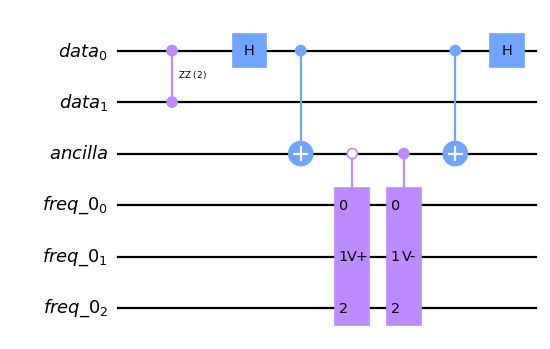


2. Native Fourier Hadamard Test Circuit:
Notice the top `ht_ancilla` controlling the entire A(U) subroutine, followed by the frequency uncomputation.


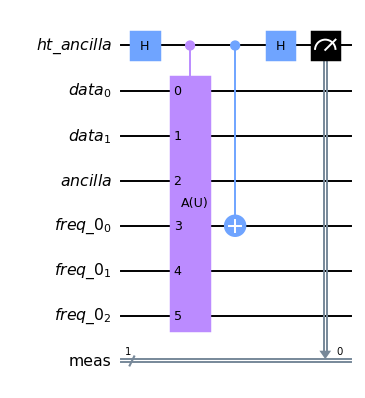


3. Quantum Overlap Kernel Circuit (Interference):
Notice the global `kernel_ancilla` acting as a switch between the A(U_x) and A(U_x') subroutines.


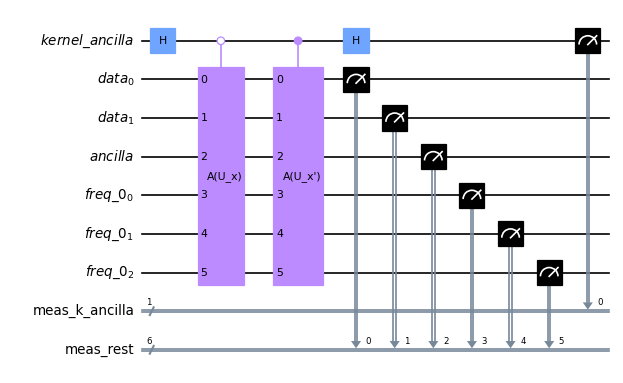

In [2]:
# --- Visualizing the Circuit Architectures ---
from src.quantum_routines import CircuitBuilder
import matplotlib.pyplot as plt

# Initialize your stack
builder = CircuitBuilder()

# Keep parameters small so the circuit fits on the screen!
num_qubits = 2
x_edges = [(0, 1)]  # A simple 2-qubit nearest-neighbor interaction
tau = 1.0
r_steps = 1
d_params = 1

# -------------------------------------------------------------------
# 1. Base A(U) Fourier Extraction Circuit (Trotterization)
# -------------------------------------------------------------------
qc_base, qr_freqs = builder.build_trotter_extraction_circuit(
    num_qubits=num_qubits, 
    x_edges=x_edges, 
    tau=tau, 
    r_steps=r_steps, 
    d_params=d_params
)

print("1. A(U) Fourier Extraction Circuit (Trotterized Dynamics):")
print("Notice the V+ and V- circular shift operations mapping the dynamics into the frequency register.")
display(qc_base.draw('mpl', style='clifford', scale=0.8))


# -------------------------------------------------------------------
# 2. Native Fourier Hadamard Test Circuit
# -------------------------------------------------------------------
target_freq = 1
qc_ht = builder.build_fourier_hadamard_test(
    num_qubits=num_qubits, 
    x_edges=x_edges, 
    tau=tau, 
    r_steps=r_steps, 
    target_freq=target_freq, 
    part='real'
)

print("\n2. Native Fourier Hadamard Test Circuit:")
print("Notice the top `ht_ancilla` controlling the entire A(U) subroutine, followed by the frequency uncomputation.")
display(qc_ht.draw('mpl', style='clifford', scale=0.7))


# -------------------------------------------------------------------
# 3. Quantum Overlap Kernel Circuit
# -------------------------------------------------------------------
x_edges_1 = [(0, 1)] # Graph 1
x_edges_2 = []       # Graph 2 (Empty)

qc_kernel = builder.build_quantum_overlap_kernel_circuit(
    num_qubits=num_qubits, 
    x_edges_1=x_edges_1, 
    x_edges_2=x_edges_2, 
    tau=tau, 
    r_steps=r_steps
)

print("\n3. Quantum Overlap Kernel Circuit (Interference):")
print("Notice the global `kernel_ancilla` acting as a switch between the A(U_x) and A(U_x') subroutines.")
display(qc_kernel.draw('mpl', style='clifford', scale=0.6, fold=60))